# Multi-species LSTM — Leave-One-Species-Out evaluation

**Question.** Can a pooled LSTM — trained on *other* fruit tree species — generalise to a
held-out species it has never seen?  And does a phylogenetic context embedding give an
advantage over a plain one-hot or no-context baseline when the species is entirely absent
from training?

**Design.**
For each held-out species *S*:
1. Train three pooled models on the remaining 6 species.
2. Train a single-species LSTM on *S*'s own temporal training split (upper bound / reference).
3. Evaluate all four models on *S*'s temporal test split.

| Model | Training data | Species context for held-out S |
|---|---|---|
| `pool_plain` | 6 species | none |
| `pool_onehot` | 6 species | zero vector (S is unknown) |
| `pool_phylo` | 6 species | phylogenetic MDS coords of S (pre-computed from all 7) |
| `single` | S only (temporal train split) | — |

The phylogeny is fitted on **all 7 species** before the loop so the held-out species has a
meaningful position in the embedding space even though no training examples come from it.

In [1]:
RETRAIN  = True   # True → retrain every model from scratch
CUTOFF   = 2006    # years < CUTOFF → train,  ≥ CUTOFF → test

DATASETS_CONFIG = {
    'Apple':   dict(key='PEP725_Apple',   obs_key='BBCH_60', name='Malus x domestica'),
    'Pear':    dict(key='PEP725_Pear',    obs_key='BBCH_60', name='Pyrus communis'),
    'Peach':   dict(key='PEP725_Peach',   obs_key='BBCH_60', name='Prunus persica'),
    'Almond':  dict(key='PEP725_Almond',  obs_key='BBCH_60', name='Prunus amygdalis'),
    'Cherry':  dict(key='PEP725_Cherry',  obs_key='BBCH_60', name='Prunus avium'),
    'Apricot': dict(key='PEP725_Apricot', obs_key='BBCH_60', name='Prunus armeniaca'),
    'Plum':    dict(key='PEP725_Plum',    obs_key='BBCH_60', name='Prunus domestica'),
}

DATA_KEYS     = ['temperature_2m_mean', 'daylight_duration']
PHYLO_K_EMBED = len(DATASETS_CONFIG)   # one MDS dimension per species

MODEL_KWARGS = dict(
    data_keys   = DATA_KEYS,
    hidden_size = 64,
    num_layers  = 2,
)
TRAIN_KWARGS = dict(
    num_epochs               = 100,
    batch_size               = 32,
    val_period               = 10,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 20,
    scheduler_decay          = 0.5,
    early_stopping           = True,
    early_stopping_patience  = 25,
    early_stopping_min_delta = 1e-4,
    early_stopping_rerun     = False,
    seed                     = 0,
    verbose                  = True,
)

In [2]:
import warnings
warnings.filterwarnings('ignore')

from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pysephone.dataset.dataset import Dataset
from pysephone.dataset.observations import Observations
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.feature_cache import FeatureCache
from pysephone.dataset.util.phylogeny import PhylogenyFeatures
from pysephone.models.lstm import LSTMModel
from pysephone.models.lstm_ctx import OneHotSpeciesLSTMModel, PhylogeneticLSTMModel
from pysephone.paths import get_data_root, get_model_dir

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 1. Load datasets

In [3]:
def target_fn(sample):
    return sample['observations']['BBCH_60']


cal = Calendar()

per_species_trn: dict[str, Dataset] = {}
per_species_tst: dict[str, Dataset] = {}

for label, cfg in DATASETS_CONFIG.items():
    cache = FeatureCache.load(FeatureCache.default_path(cfg['key'], DATA_KEYS))
    ds    = Dataset.load(cfg['key'], calendar=cal, feature_providers=[cache])
    ys_trn = [y for y in ds.years if y <  CUTOFF]
    ys_tst = [y for y in ds.years if y >= CUTOFF]
    per_species_trn[label] = ds.select_years(ys_trn)
    per_species_tst[label] = ds.select_years(ys_tst)
    print(f'{label}: train={len(per_species_trn[label])}  test={len(per_species_tst[label])}')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 44070.59it/s]


Apple: train=4154  test=2607


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 47203.21it/s]


Pear: train=979  test=2305


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 43866.62it/s]


...

Cherry: train=4768  test=2797


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 45436.99it/s]


Apricot: train=15  test=175


Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 43974.99it/s]


Plum: train=2420  test=684


## 2. Fit phylogenetic embedding on all 7 species

The embedding is computed once from all species — including the ones that will later be
held out.  This gives the phylo model a meaningful context vector for the held-out species
at inference time even though it was never trained on that species' observations.

In [4]:
_pool_cache  = FeatureCache.load(FeatureCache.default_path('PEP725_fruit_trees', DATA_KEYS))

all_obs = reduce(
    Observations.merge,
    [per_species_trn[l]._obs for l in DATASETS_CONFIG],
)
phylo = PhylogenyFeatures(k_embed=PHYLO_K_EMBED, output=['mds']).fit(all_obs)
species_keys_all = list(phylo.species_keys)
mds_coords_all   = np.asarray(phylo.mds_coords)

print(f'Phylo fitted on {len(species_keys_all)} species, MDS shape: {mds_coords_all.shape}')
for k in species_keys_all:
    print(f'  {k}')

Phylo fitted on 7 species, MDS shape: (7, 6)
  ('pep725', 202)
  ('pep725', 205)
  ('pep725', 220)
  ('pep725', 222)
  ('pep725', 225)
  ('pep725', 227)
  ('pep725', 782)


## 3. Helpers

In [5]:
def train_or_load(model_name, model_cls, model_kwargs, dataset):
    path = get_model_dir(get_data_root(), model_name) / f'{model_name}.pt'
    if not RETRAIN and path.exists():
        model = torch.load(path, weights_only=False, map_location=DEVICE)
        model.eval()
        print(f'  [loaded]   {model_name}')
        return model
    print(f'  [training] {model_name}  (n={len(dataset)}) ...')
    model, _ = model_cls.fit(
        target_fn    = target_fn,
        dataset      = dataset,
        model_kwargs = model_kwargs,
        device       = DEVICE,
        **TRAIN_KWARGS,
    )
    model.save(model_name)
    model.eval()
    print(f'  [saved]    {model_name}')
    return model


def evaluate(model, dataset):
    if hasattr(model, 'to'):
        model.to(DEVICE)
    errors, ys_true, ys_pred = [], [], []
    for sample in dataset.iter_items():
        try:
            target_date = target_fn(sample)
        except KeyError:
            continue
        pred_date, _ = model.predict(sample, device=DEVICE)
        season_start = np.datetime64(sample['season_start'], 'D')
        t_ix = int((np.datetime64(target_date, 'D') - season_start) / np.timedelta64(1, 'D'))
        p_ix = int((np.datetime64(pred_date,   'D') - season_start) / np.timedelta64(1, 'D'))
        ys_true.append(t_ix); ys_pred.append(p_ix); errors.append(p_ix - t_ix)
    if not errors:
        return None
    e = np.array(errors, dtype=float)
    return {
        'n':       len(e),
        'MAE':     float(np.abs(e).mean()),
        'RMSE':    float(np.sqrt((e**2).mean())),
        'bias':    float(e.mean()),
        'ys_true': np.array(ys_true),
        'ys_pred': np.array(ys_pred),
    }

## 4. Leave-one-species-out training loop

In [6]:
loso_results: dict[str, dict[str, dict]] = {}   # {held_out: {model: metrics}}

for held_out in DATASETS_CONFIG:
    print(f'\n══ Held out: {held_out} ══════════════════════════════════════════')
    train_labels = [l for l in DATASETS_CONFIG if l != held_out]

    # ── Pooled training dataset (6 species) ──────────────────────────────
    pooled_obs = reduce(
        Observations.merge,
        [per_species_trn[l]._obs for l in train_labels],
    )
    ds_pool = Dataset(pooled_obs, calendar=cal, feature_providers=[_pool_cache])

    # Species keys for the 6 training species (for one-hot)
    species_keys_train = [k for k in species_keys_all
                          if k in {(str(ix[0]), int(ix[3])) for ix in ds_pool.iter_index()}]

    # ── Train models ─────────────────────────────────────────────────────
    prefix = f'loso_{held_out.lower()}'

    plain = train_or_load(
        f'{prefix}_pool_plain', LSTMModel,
        dict(MODEL_KWARGS),
        ds_pool,
    )
    onehot = train_or_load(
        f'{prefix}_pool_onehot', OneHotSpeciesLSTMModel,
        dict(MODEL_KWARGS, species_keys=species_keys_train),
        ds_pool,
    )
    # Phylo: pass ALL 7 species so held-out species has real coords at inference
    phylo_model = train_or_load(
        f'{prefix}_pool_phylo', PhylogeneticLSTMModel,
        dict(MODEL_KWARGS, species_keys=species_keys_all, mds_coords=mds_coords_all),
        ds_pool,
    )
    # Single-species: trained on held-out species' own data
    single = train_or_load(
        f'{prefix}_single', LSTMModel,
        dict(MODEL_KWARGS),
        per_species_trn[held_out],
    )

    # ── Evaluate on held-out species test split ───────────────────────────
    ds_tst = per_species_tst[held_out]
    loso_results[held_out] = {
        'pool_plain':  evaluate(plain,       ds_tst),
        'pool_onehot': evaluate(onehot,      ds_tst),
        'pool_phylo':  evaluate(phylo_model, ds_tst),
        'single':      evaluate(single,      ds_tst),
    }

    for name, m in loso_results[held_out].items():
        if m:
            print(f'  {name:<14}  MAE={m["MAE"]:5.1f}  n={m["n"]}')


══ Held out: Apple ══════════════════════════════════════════
  [training] loso_apple_pool_plain  (n=9258) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.14932: 100%|██████████| 215/215 [00:01<00:00, 212.83it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.04693: 100%|██████████| 215/215 [00:00<00:00, 315.83it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.04456: 100%|██████████| 215/215 [00:00<00:00, 311.62it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.04325: 100%|██████████| 215/215 [00:00<00:00, 318.25it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.04299: 100%|██████████| 215/215 [00:00<00:00, 309.54it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.04143: 100%|██████████| 215/215 [00:00<00:00, 297.79it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.04114: 100%|██████████| 215/215 [00:00<00:00, 297.03it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.04048: 100%|██████████| 215/215 [00:00<00:00, 288.37it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.03984: 100%|██████████| 215/215 [00:00<00:00, 310.12it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.03942: 1

  [saved]    loso_apple_pool_plain
  [training] loso_apple_pool_onehot  (n=9258) ...


OneHotSpeciesLSTMModel epoch [    1/100] lr=1.00e-03 loss=0.14158: 100%|██████████| 215/215 [00:00<00:00, 291.76it/s]
OneHotSpeciesLSTMModel epoch [    2/100] lr=1.00e-03 loss=0.04313: 100%|██████████| 215/215 [00:00<00:00, 272.82it/s]
OneHotSpeciesLSTMModel epoch [    3/100] lr=1.00e-03 loss=0.03940: 100%|██████████| 215/215 [00:00<00:00, 241.69it/s]
OneHotSpeciesLSTMModel epoch [    4/100] lr=1.00e-03 loss=0.03732: 100%|██████████| 215/215 [00:00<00:00, 278.63it/s]
OneHotSpeciesLSTMModel epoch [    5/100] lr=1.00e-03 loss=0.03688: 100%|██████████| 215/215 [00:00<00:00, 272.31it/s]
OneHotSpeciesLSTMModel epoch [    6/100] lr=1.00e-03 loss=0.03573: 100%|██████████| 215/215 [00:00<00:00, 269.23it/s]
OneHotSpeciesLSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03523: 100%|██████████| 215/215 [00:00<00:00, 272.57it/s]
OneHotSpeciesLSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03488: 100%|██████████| 215/215 [00:00<00:00, 265.17it/s]
OneHotSpeciesLSTMModel epoch [    9/100] lr=1.00e-03 los

  [saved]    loso_apple_pool_onehot
  [training] loso_apple_pool_phylo  (n=9258) ...


...

  [saved]    loso_plum_pool_onehot
  [training] loso_plum_pool_phylo  (n=10992) ...


PhylogeneticLSTMModel epoch [    1/100] lr=1.00e-03 loss=0.11949: 100%|██████████| 253/253 [00:00<00:00, 275.76it/s]
PhylogeneticLSTMModel epoch [    2/100] lr=1.00e-03 loss=0.03834: 100%|██████████| 253/253 [00:00<00:00, 279.65it/s]
PhylogeneticLSTMModel epoch [    3/100] lr=1.00e-03 loss=0.03582: 100%|██████████| 253/253 [00:00<00:00, 308.67it/s]
PhylogeneticLSTMModel epoch [    4/100] lr=1.00e-03 loss=0.03489: 100%|██████████| 253/253 [00:00<00:00, 278.50it/s]
PhylogeneticLSTMModel epoch [    5/100] lr=1.00e-03 loss=0.03432: 100%|██████████| 253/253 [00:00<00:00, 298.36it/s]
PhylogeneticLSTMModel epoch [    6/100] lr=1.00e-03 loss=0.03364: 100%|██████████| 253/253 [00:00<00:00, 307.48it/s]
PhylogeneticLSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03284: 100%|██████████| 253/253 [00:00<00:00, 300.01it/s]
PhylogeneticLSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03220: 100%|██████████| 253/253 [00:00<00:00, 255.25it/s]
PhylogeneticLSTMModel epoch [    9/100] lr=1.00e-03 loss=0.03188

  [saved]    loso_plum_pool_phylo
  [training] loso_plum_single  (n=2420) ...


LSTMModel epoch [    1/100] lr=1.00e-03 loss=0.37997: 100%|██████████| 58/58 [00:00<00:00, 284.74it/s]
LSTMModel epoch [    2/100] lr=1.00e-03 loss=0.05613: 100%|██████████| 58/58 [00:00<00:00, 345.60it/s]
LSTMModel epoch [    3/100] lr=1.00e-03 loss=0.04392: 100%|██████████| 58/58 [00:00<00:00, 340.06it/s]
LSTMModel epoch [    4/100] lr=1.00e-03 loss=0.04053: 100%|██████████| 58/58 [00:00<00:00, 353.15it/s]
LSTMModel epoch [    5/100] lr=1.00e-03 loss=0.04065: 100%|██████████| 58/58 [00:00<00:00, 360.60it/s]
LSTMModel epoch [    6/100] lr=1.00e-03 loss=0.03902: 100%|██████████| 58/58 [00:00<00:00, 357.34it/s]
LSTMModel epoch [    7/100] lr=1.00e-03 loss=0.03704: 100%|██████████| 58/58 [00:00<00:00, 354.65it/s]
LSTMModel epoch [    8/100] lr=1.00e-03 loss=0.03693: 100%|██████████| 58/58 [00:00<00:00, 332.59it/s]
LSTMModel epoch [    9/100] lr=1.00e-03 loss=0.03669: 100%|██████████| 58/58 [00:00<00:00, 349.64it/s]
LSTMModel epoch [   10/100] lr=1.00e-03 loss=0.03616: 100%|██████████| 58

  [saved]    loso_plum_single
  pool_plain      MAE=  6.5  n=684
  pool_onehot     MAE=  8.7  n=684
  pool_phylo      MAE= 57.3  n=684
  single          MAE=  6.0  n=684


## 5. Results table

In [7]:
MODEL_ORDER  = ['pool_plain', 'pool_onehot', 'pool_phylo', 'single']
MODEL_COLORS = {
    'pool_plain':  '#7f8c8d',
    'pool_onehot': '#2980b9',
    'pool_phylo':  '#27ae60',
    'single':      '#c0392b',
}
MODEL_LABELS = {
    'pool_plain':  'pool plain',
    'pool_onehot': 'pool one-hot',
    'pool_phylo':  'pool phylo',
    'single':      'single',
}

rows = []
for held_out, results in loso_results.items():
    for model_name in MODEL_ORDER:
        m = results.get(model_name)
        if m is None:
            continue
        rows.append({
            'held_out': held_out,
            'model':    model_name,
            'n_test':   m['n'],
            'MAE':      round(m['MAE'],  2),
            'RMSE':     round(m['RMSE'], 2),
            'bias':     round(m['bias'], 2),
        })

df = pd.DataFrame(rows)
pivot = df.pivot(index='held_out', columns='model', values='MAE').reindex(
    columns=MODEL_ORDER, index=list(DATASETS_CONFIG.keys())
)
display(pivot.round(2))

print('\nMean MAE across held-out species:')
display(pivot.mean().round(2).to_frame('mean MAE').T)

model,pool_plain,pool_onehot,pool_phylo,single
held_out,,,,
Apple,7.88,14.14,53.09,3.77
Pear,5.38,7.91,55.79,5.42
Peach,16.64,7.86,78.86,7.00
Almond,48.86,45.14,40.00,16.02
Cherry,9.72,5.90,66.11,4.68
Apricot,16.67,11.78,144.61,13.74
Plum,6.55,8.69,57.33,6.04



Mean MAE across held-out species:


model,pool_plain,pool_onehot,pool_phylo,single
mean MAE,15.96,14.49,70.83,8.1


## 6. Visualisation — MAE per held-out species

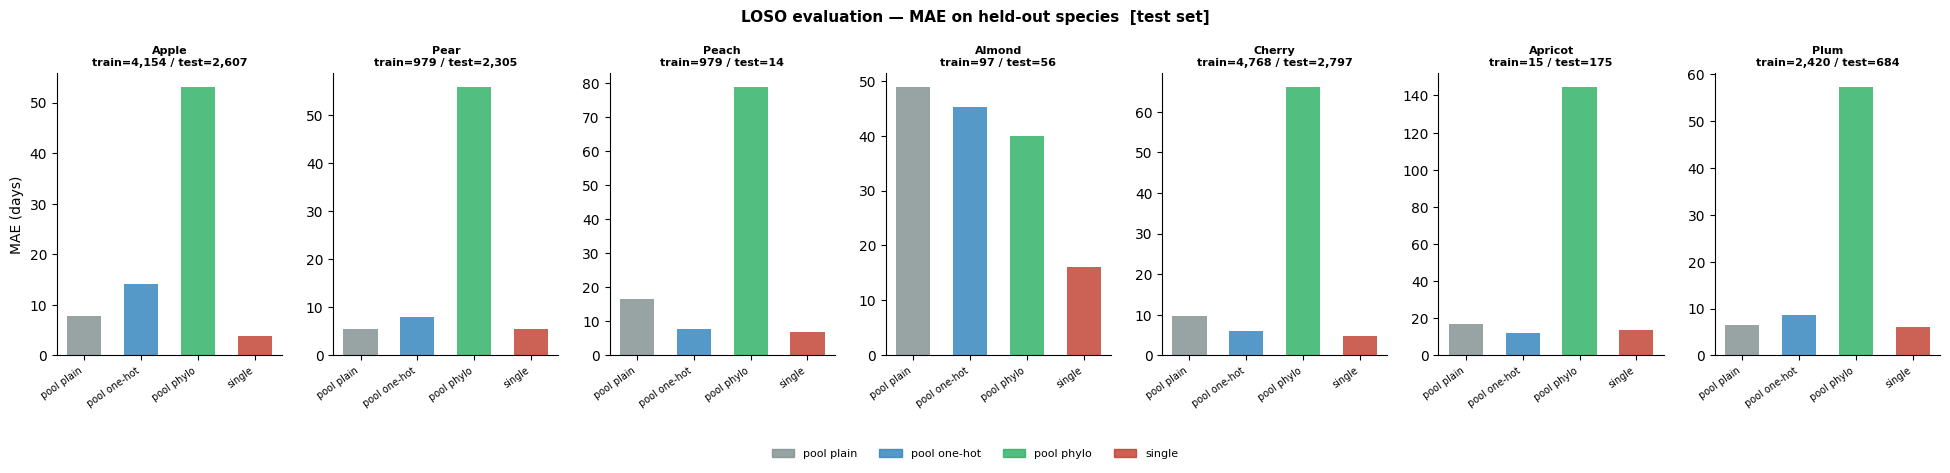

In [8]:
labels    = list(DATASETS_CONFIG.keys())
n_species = len(labels)
x         = np.arange(len(MODEL_ORDER))
width     = 0.6

fig, axes = plt.subplots(1, n_species, figsize=(2.8 * n_species, 4.5), sharey=False)
fig.suptitle('LOSO evaluation — MAE on held-out species  [test set]',
             fontweight='bold', fontsize=11)

for ax, sp in zip(axes, labels):
    maes   = [loso_results[sp].get(m, {}).get('MAE', np.nan) for m in MODEL_ORDER]
    colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
    bars   = ax.bar(x, maes, width=width, color=colors, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER],
                       rotation=35, ha='right', fontsize=7)
    n_trn = len(per_species_trn[sp])
    n_tst = len(per_species_tst[sp])
    ax.set_title(f'{sp}\ntrain={n_trn:,} / test={n_tst:,}', fontsize=8, fontweight='bold')
    ax.set_ylabel('MAE (days)' if ax == axes[0] else '')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=MODEL_COLORS[m], alpha=0.8) for m in MODEL_ORDER]
fig.legend(handles, [MODEL_LABELS[m] for m in MODEL_ORDER],
           loc='lower center', ncol=4, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 7. Does pool_phylo benefit more for small-data species?

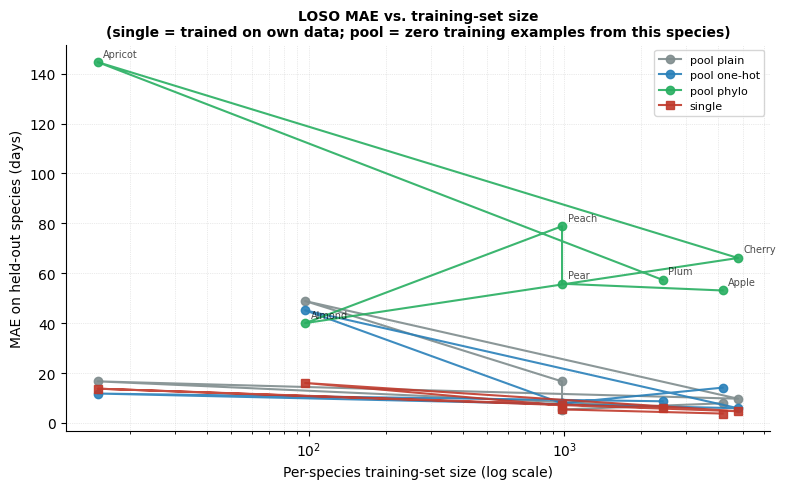

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xscale('log')

sizes = np.array([len(per_species_trn[s]) for s in labels])

for model_name in MODEL_ORDER:
    maes = np.array([loso_results[s].get(model_name, {}).get('MAE', np.nan) for s in labels])
    marker = 's' if model_name == 'single' else 'o'
    ax.plot(sizes, maes, marker=marker, lw=1.5,
            color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name], alpha=0.9)

for sp, size in zip(labels, sizes):
    y = loso_results[sp].get('pool_phylo', {}).get('MAE', np.nan)
    if not np.isnan(y):
        ax.annotate(sp, (size, y), fontsize=7, alpha=0.7,
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Per-species training-set size (log scale)')
ax.set_ylabel('MAE on held-out species (days)')
ax.set_title('LOSO MAE vs. training-set size\n'
             '(single = trained on own data; pool = zero training examples from this species)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)
plt.tight_layout()
plt.show()